In [2]:
import math
from dataclasses import dataclass
from typing import Dict, Tuple, Callable
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
class ODEState:
    def __init__(
            self,
            t: float,
            y: Tuple[float, ...]
    ):
        self.t= t
        self.y= y



In [4]:
class DifferentialEquation:
    def __init__(
            self,
            derivative: Callable[[float, Tuple[float, ...]], Tuple[float, ...]],
            initial_time: float,
            initial_state: Tuple[float,...],
    ):
        self.derivative = derivative
        self.initial_time = initial_time
        self.initial_state = initial_state


    def evaluate(
            self,
            t: float,
            state: Tuple[float, ...]
    ):
        return self.derivative(t, state)

In [5]:
class ODESolver:
    def __init__(
            self,
            ode: DifferentialEquation,
            step_size: float,
    ):
        self.ode = ode
        self.step_size = step_size

    def step(
            self,
            state: ODEState,
            step_size: float
    ) -> ODEState:
        raise NotImplementedError("This method should be implemented by subclasses.")

    def solve(
            self,
            final_time: float
    ) -> list[ODEState]:
        
        state = ODEState(
            t = self.ode.initial_time,
            y= self.ode.initial_state
        )

        states = [state]

        while state.t < final_time:
            remaining_time = final_time-state.t
            step_size=min(self.step_size,remaining_time)


            state = self.step(
                state,
                step_size
            )
            states.append(state)

        return states

In [6]:
class EulerMethod(ODESolver):

    def step(
            self,
            state: ODEState,
            step_size: float,
    )-> ODEState:

        t = state.t
        y = state.y

        dydt = self.ode.evaluate(t, y)

        next_y = tuple(
            yi + step_size * dyi
            for yi, dyi in zip(y, dydt)
        )

        return ODEState(
            t + step_size,
            next_y
        )

    

In [7]:
class SimulationEngine:
    """
    Orchestrates the numerical solution of the differential equation.
    """

    def __init__(self, solver: ODESolver):
        self.solver = solver

    def run(self, final_time: float) -> list[ODEState]:
        return self.solver.solve(final_time)

In [8]:
g = 9.81

L = 1

mu= .2

def derivative(
    t: float,
    state: Tuple[float, ...]
) -> Tuple[float, ...]:
    x, velocity = state

    dx_dt = velocity
    dvelocity_dt = (
        -g/L * np.sin(x) - mu * velocity
    )

    return (
        dx_dt,
        dvelocity_dt,
    )


edo = DifferentialEquation(
    derivative=derivative,
    initial_time=0,
    initial_state=(
        np.deg2rad(-145),
        6.4
    ),
)

solver = EulerMethod(
    edo,
    step_size=0.001
)

engine = SimulationEngine(solver)

solution = engine.run(
    final_time=40
)


times = [state.t for state in solution]
positions = [state.y[0] for state in solution]
velocities = [state.y[1] for state in solution]

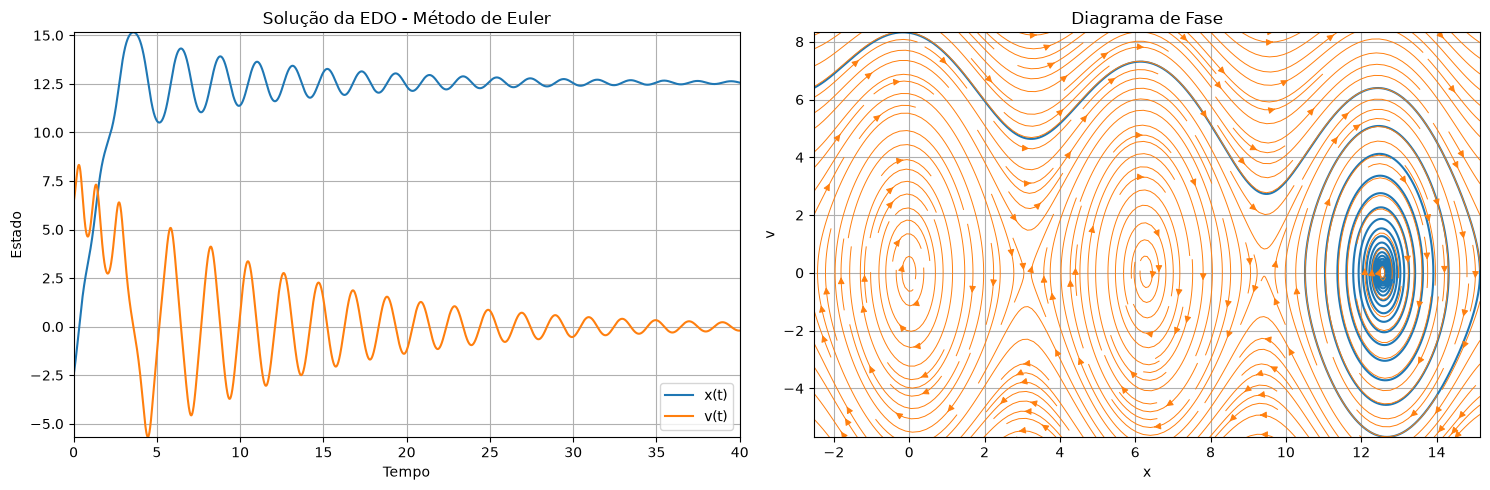

In [9]:


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico temporal

axes[0].plot(
    times,
    positions,
    label="x(t)"
)

axes[0].plot(
    times,
    velocities,
    label="v(t)"
)

axes[0].set_xlim(
    min(times),
    max(times)
)

axes[0].set_ylim(
    min(min(positions),min(velocities)),
    max(max(positions),max(velocities))
)

axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("Estado")
axes[0].set_title("Solução da EDO - Método de Euler")
axes[0].grid()
axes[0].legend()


# Diagrama de fase
axes[1].plot(
    positions,
    velocities
)

axes[1].set_xlim(
    min(positions),
    max(positions)
)

axes[1].set_ylim(
    min(velocities),
    max(velocities)
)

x_min = min(positions)
x_max = max(positions)

velocity_min = min(velocities)
velocity_max = max(velocities)

x_grid = np.linspace(
    x_min,
    x_max,
    120
)

velocity_min = min(velocities) - 1
velocity_max = max(velocities) + 1

velocity_grid = np.linspace(
    velocity_min,
    velocity_max,
    120
)

X, V = np.meshgrid(
    x_grid,
    velocity_grid
)

Dx, Dvelocity = derivative(
    0.0,
    (X, V)
)

axes[1].streamplot(
    X,
    V,
    Dx,
    Dvelocity,
    density=(3.0, 2.0),
    linewidth=0.7,
    arrowsize=1
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].set_title("Diagrama de Fase")
axes[1].grid()


plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import HTML, display

import matplotlib as mpl

mpl.rcParams["animation.embed_limit"] = 400  #memory used in Mega bytes for the animation

fig, axes = plt.subplots(1, 3, figsize=(20, 5))


x_min = min(positions)
x_max = max(positions)

velocity_min = min(velocities)
velocity_max = max(velocities)

x_margin = 0.05 * (x_max - x_min)
velocity_margin = 0.05 * (velocity_max - velocity_min)

x_min -= x_margin
x_max += x_margin

velocity_min -= velocity_margin
velocity_max += velocity_margin

#####################
# Gráfico temporal
#####################

line_position, = axes[0].plot(
    [],
    [],
    label="x(t)"
)

line_velocity, = axes[0].plot(
    [],
    [],
    label="v(t)"
)

position_point, = axes[0].plot(
    [],
    [],
    "o"
)

velocity_point, = axes[0].plot(
    [],
    [],
    "o"
)


axes[0].set_xlim(
    min(times),
    max(times)
)

axes[0].set_ylim(
    min(min(positions),min(velocities)),
    max(max(positions),max(velocities))
)

axes[0].set_xlabel("Tempo")
axes[0].set_ylabel("Estado")
axes[0].set_title("Solução da EDO - Método de Euler")
axes[0].grid()
axes[0].legend()

#####################
#campo vetorial
#####################

x_grid = np.linspace(
    x_min,
    x_max,
    150
)

velocity_grid = np.linspace(
    velocity_min,
    velocity_max,
    150
)

X, V = np.meshgrid(
    x_grid,
    velocity_grid
)

Dx, Dvelocity = derivative(
    0.0,
    (X, V)
)


axes[1].streamplot(
    X,
    V,
    Dx,
    Dvelocity,
    density=(3.0, 2.0),
    linewidth=0.6,
    arrowsize=0.8
)

# Diagrama de fase
phase_line, = axes[1].plot(
    [],
    [],
    linewidth=2,
    label="Trajectory"
)

phase_point, = axes[1].plot(
    [],
    [],
    "o"
)

axes[1].set_xlim(
    x_min,
    x_max
)

axes[1].set_ylim(
    velocity_min,
    velocity_max
)

axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].set_title("Diagrama de Fase")
axes[1].grid()

#####################
# Pendulo
#####################

rod, = axes[2].plot(
    [],
    [],
    linewidth=3
)

bob, = axes[2].plot(
    [],
    [],
    "o",
    markersize=16
)

pivot, = axes[2].plot(
    [0],
    [0],
    "o",
    markersize=8
)

axes[2].set_xlim(
    -1.25 * L,
    1.25 * L
)

axes[2].set_ylim(
    -1.25 * L,
    1.25 * L
)

axes[2].set_aspect("equal")

axes[2].set_xlabel("x")
axes[2].set_ylabel("y")

axes[2].set_title("Pêndulo")

axes[2].grid()



def update(frame):

    current_time = times[frame]
    current_pos = positions[frame]
    current_velocity = velocities[frame]

    # --------------------------------------------------------
    # Gráfico temporal
    # --------------------------------------------------------

    line_position.set_data(
        times[:frame + 1],
        positions[:frame + 1]
    )

    line_velocity.set_data(
        times[:frame + 1],
        velocities[:frame + 1]
    )

    position_point.set_data(
        [current_time],
        [current_pos]
    )

    velocity_point.set_data(
        [current_time],
        [current_velocity]
    )

    # --------------------------------------------------------
    # Diagrama de fase
    # --------------------------------------------------------

    phase_line.set_data(
        positions[:frame + 1],
        velocities[:frame + 1]
    )

    phase_point.set_data(
        [current_pos],
        [current_velocity]
    )

    # --------------------------------------------------------
    # Pêndulo
    # --------------------------------------------------------

    bob_x = (
        L * np.sin(current_pos)
    )

    bob_y = (
        -L * np.cos(current_pos)
    )

    rod.set_data(
        [0, bob_x],
        [0, bob_y]
    )

    bob.set_data(
        [bob_x],
        [bob_y]
    )

    # --------------------------------------------------------
    # Títulos
    # --------------------------------------------------------

    axes[0].set_title(
        f"Solução da EDO - t = {current_time:.2f}"
    )

    axes[2].set_title(
        f"x = {current_pos:.2f} rad\n"
        f"v = {current_velocity:.2f} rad/s"
    )

    return (
        line_position,
        line_velocity,
        position_point,
        velocity_point,
        phase_line,
        phase_point,
        rod,
        bob
    )

n_frames = 400

frames = np.linspace(
    0,
    len(times) - 1,
    n_frames,
    dtype=int
)

animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=20,
    blit=False,
    repeat=False
)

plt.close(fig)

display(
    HTML(
        animation.to_jshtml()
    )
)